Telecom X – Parte 2: Predicción de Cancelación (Churn)

📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.
🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

**IMPORTAR DATOS **

In [9]:

import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# 1) Cargar JSON (robusto)
raw = pd.read_json(url)

# 2) Aplanar si viene anidado (dicts dentro de columnas)
def flatten_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    changed = True
    while changed:
        changed = False
        # columnas que contienen dict en alguna fila
        dict_cols = [c for c in out.columns if out[c].apply(lambda x: isinstance(x, dict)).any()]
        if dict_cols:
            changed = True
            for c in dict_cols:
                expanded = pd.json_normalize(out[c]).add_prefix(f"{c}.")
                out = out.drop(columns=[c]).reset_index(drop=True)
                out = pd.concat([out.reset_index(drop=True), expanded.reset_index(drop=True)], axis=1)

    # columnas que contienen listas (a veces hay listas de servicios, etc.)
    list_cols = [c for c in out.columns if out[c].apply(lambda x: isinstance(x, list)).any()]
    for c in list_cols:
        # si son listas simples -> las convertimos a texto unido
        out[c] = out[c].apply(lambda x: "|".join(map(str, x)) if isinstance(x, list) else x)

    return out

df = flatten_df(raw)

print(df.shape)
display(df.head())

(7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**TRANSFORMACION DE DATOS A CSV**

In [10]:

df.to_csv("datos_tratados.csv", index=False)

**IMPORTANDO DATOS **

In [12]:
import pandas as pd
import numpy as np

# Cargar archivo
df = pd.read_csv("/content/datos_tratados.csv")

print("Shape:", df.shape)
display(df.head())
print("\nTipos de datos:")
display(df.dtypes)
print("\nValores nulos:")
display(df.isna().sum())

Shape: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Tipos de datos:


,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object



Valores nulos:


,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [13]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

**ELIMINAR COLUMNS IRRELEVANTES **

In [14]:
# Detectar columnas tipo ID automáticamente
id_columns = [
    col for col in df.columns
    if (
        "id" in col.lower() or
        "cliente" in col.lower() and "id" in col.lower()
    )
]

print("Columnas identificadas como ID:", id_columns)

Columnas identificadas como ID: ['customerID']


In [15]:
df.columns


Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

**Separar variables numéricas y categóricas**

In [16]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly']
Categóricas: ['customerID', 'Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Total']


**Aplicar One-Hot Encoding correctamente**

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Pipeline numérico
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Pipeline categórico
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

**Conversion **

In [18]:
# Eliminar identificador
df = df.drop(columns=["customerID"], errors="ignore")

# Convertir Total Charges a numérico si existe
if "account.Charges.Total" in df.columns:
    df["account.Charges.Total"] = pd.to_numeric(
        df["account.Charges.Total"], errors="coerce"
    )

# Volver a detectar columnas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas corregidas:", num_cols)
print("Categóricas corregidas:", cat_cols)

# Aplicar One-Hot nuevamente
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print("\nNuevo shape después de encoding:", df_encoded.shape)

Numéricas corregidas: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
Categóricas corregidas: ['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Nuevo shape después de encoding: (7267, 47)


**limpiar**

In [19]:
import pandas as pd
import numpy as np

# Cargar datos
df = pd.read_csv("/content/datos_tratados.csv")

# 1️⃣ Eliminar identificador
df = df.drop(columns=["customerID"], errors="ignore")

# 2️⃣ Convertir Total Charges a numérico si está como texto
if "account.Charges.Total" in df.columns:
    df["account.Charges.Total"] = pd.to_numeric(
        df["account.Charges.Total"],
        errors="coerce"
    )

print("Shape después de limpieza:", df.shape)

Shape después de limpieza: (7267, 20)


**Separar variables**

In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
Categóricas: ['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']


**Aplicar One-Hot Encoding**

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"   # equivalente a drop_first=True
    ))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

**Calcula la proporción de clientes que cancelaron**

In [23]:
import pandas as pd

# Cargar datos
df = pd.read_csv("/content/datos_tratados.csv")

# Eliminar ID si existe
df = df.drop(columns=["customerID"], errors="ignore")

# Definir columna objetivo
target_col = "Churn"   # cambia si tiene otro nombre

# 🔹 Conteo absoluto
conteo = df[target_col].value_counts()

# 🔹 Proporción (porcentaje)
proporcion = df[target_col].value_counts(normalize=True) * 100

print("Conteo absoluto:")
print(conteo)

print("\nProporción (%):")
print(proporcion.round(2))

Conteo absoluto:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporción (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**visualizar**

In [24]:
balance_df = pd.DataFrame({
    "Cantidad": conteo,
    "Porcentaje (%)": proporcion.round(2)
})

print(balance_df)

       Cantidad  Porcentaje (%)
Churn                          
No         5174           73.46
Yes        1869           26.54


**Balancear**

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/datos_tratados.csv")

# (opcional) eliminar ID
df = df.drop(columns=["customerID"], errors="ignore")

target_col = "Churn"

# 1) Ver valores únicos ANTES (para diagnóstico)
print("Valores únicos en Churn (raw):")
print(df[target_col].astype(str).value_counts(dropna=False).head(20))

# 2) Limpieza + mapeo robusto
s = df[target_col]

# Normalizar a string limpio (sin espacios, lower)
s_clean = (
    s.astype(str)
     .str.strip()
     .str.lower()
     .replace({"nan": np.nan, "none": np.nan, "": np.nan})
)

# Mapeo amplio
mapa = {
    "yes": 1, "y": 1, "si": 1, "sí": 1, "true": 1, "1": 1,
    "no": 0, "n": 0, "false": 0, "0": 0
}

df[target_col] = s_clean.map(mapa)

# 3) Revisar cuántos NaN quedaron
n_nan = df[target_col].isna().sum()
print(f"\nNaN en target después del mapeo: {n_nan}")

# Mostrar qué valores no se pudieron mapear (si los hay)
if n_nan > 0:
    valores_no_mapeados = s_clean[df[target_col].isna()].value_counts().head(20)
    print("\nValores no mapeados (revisar):")
    print(valores_no_mapeados)

    # 4) Solución práctica: eliminar filas con target inválido
    df = df.dropna(subset=[target_col])

# Ya con target limpio:
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# 5) Split estratificado (ya no debe fallar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nSplit OK ✅")
print("Train:", y_train.value_counts())
print("Test :", y_test.value_counts())

Valores únicos en Churn (raw):
Churn
No     5174
Yes    1869
nan     224
Name: count, dtype: int64

NaN en target después del mapeo: 224

Valores no mapeados (revisar):
Series([], Name: count, dtype: int64)

Split OK ✅
Train: Churn
0    4139
1    1495
Name: count, dtype: int64
Test : Churn
0    1035
1     374
Name: count, dtype: int64


In [29]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Distribución original:")
print(y_train.value_counts())

print("\nDespués de Undersampling:")
print(y_train_under.value_counts())

Distribución original:
Churn
0    4139
1    1495
Name: count, dtype: int64

Después de Undersampling:
Churn
0    1495
1    1495
Name: count, dtype: int64


In [30]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("\nDespués de Oversampling:")
print(y_train_over.value_counts())


Después de Oversampling:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Detectar columnas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Preprocesamiento
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Transformar solo TRAIN
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

# Aplicar SMOTE SOLO en train
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed, y_train
)

print("\nDespués de SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Después de SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


**Normalización o Estandarización**

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Detectar columnas
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['int64','float64']).columns.tolist()

# Pipeline numérico con escalado
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

**Correlación y Selección de Variables**

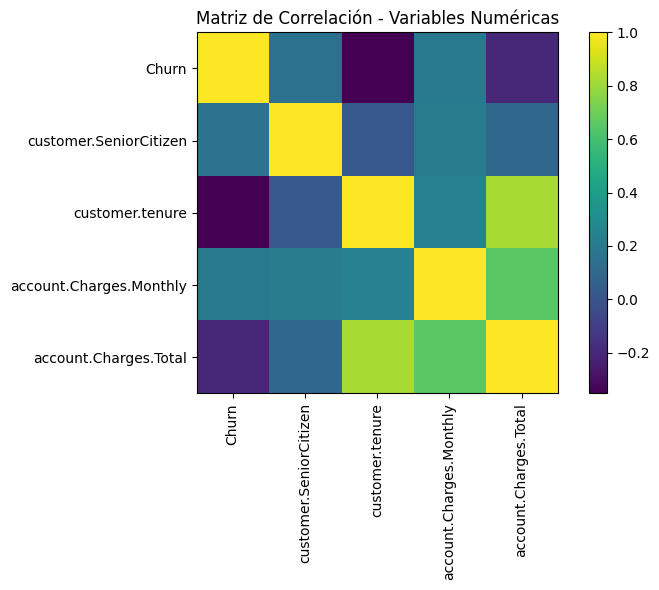


Correlación con la variable objetivo (Churn):
Churn                      1.000000
account.Charges.Monthly    0.193356
customer.SeniorCitizen     0.150889
account.Charges.Total     -0.199484
customer.tenure           -0.352229
Name: Churn, dtype: float64


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Cargar datos
df = pd.read_csv("/content/datos_tratados.csv")

# 2️⃣ Eliminar ID si existe
df = df.drop(columns=["customerID"], errors="ignore")

# 3️⃣ Convertir TotalCharges a numérico si es necesario
if "account.Charges.Total" in df.columns:
    df["account.Charges.Total"] = pd.to_numeric(
        df["account.Charges.Total"],
        errors="coerce"
    )

# 4️⃣ Convertir target a numérico si está como texto
target_col = "Churn"
if df[target_col].dtype == "object":
    df[target_col] = df[target_col].map({"Yes": 1, "No": 0})

# 5️⃣ Seleccionar solo variables numéricas
numeric_df = df.select_dtypes(include=[np.number])

# 6️⃣ Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# 7️⃣ Visualizar matriz
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)),
           corr_matrix.columns,
           rotation=90)

plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)

plt.title("Matriz de Correlación - Variables Numéricas")
plt.tight_layout()
plt.show()

# 8️⃣ Mostrar correlación con Churn ordenada
print("\nCorrelación con la variable objetivo (Churn):")
print(corr_matrix[target_col].sort_values(ascending=False))

Análisis Dirigido

<Figure size 640x480 with 0 Axes>

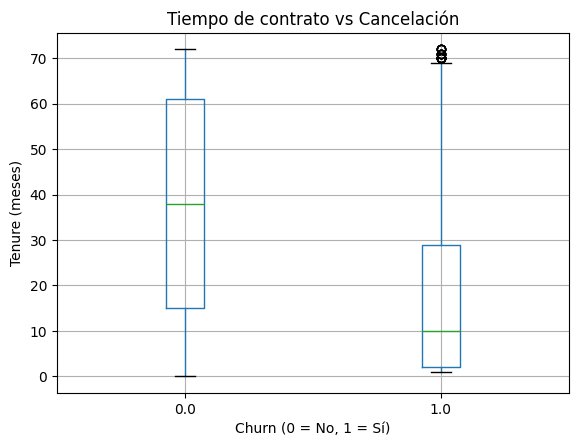

<Figure size 640x480 with 0 Axes>

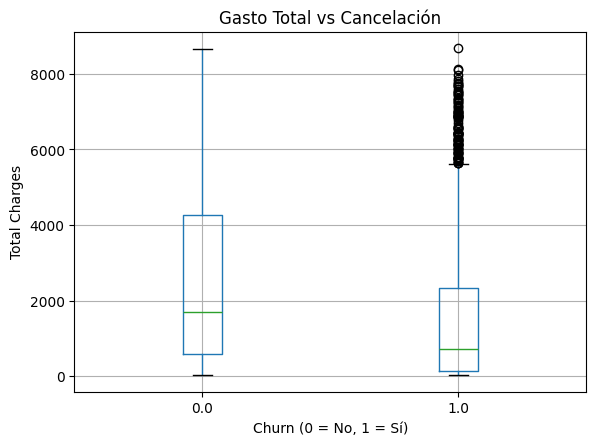

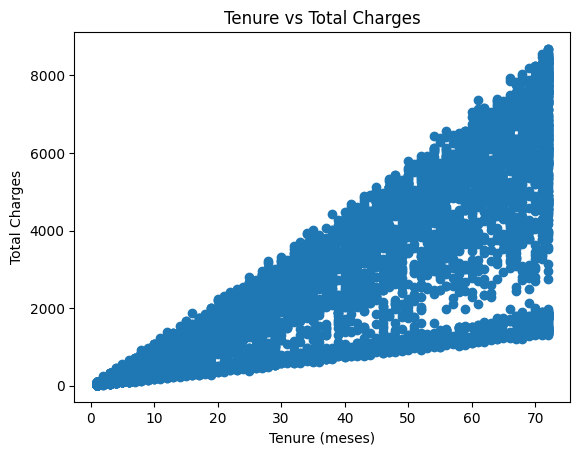

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Cargar datos
df = pd.read_csv("/content/datos_tratados.csv")

# 2️⃣ Limpieza básica
df = df.drop(columns=["customerID"], errors="ignore")

# Convertir TotalCharges a numérico si es necesario
if "account.Charges.Total" in df.columns:
    df["account.Charges.Total"] = pd.to_numeric(
        df["account.Charges.Total"], errors="coerce"
    )

# Convertir Churn a 0/1 si es texto
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ==========================================================
# 📌 1) BOXPLOT: Tenure vs Cancelación
# ==========================================================

plt.figure()
df.boxplot(column="customer.tenure", by="Churn")
plt.title("Tiempo de contrato vs Cancelación")
plt.suptitle("")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Tenure (meses)")
plt.show()


# ==========================================================
# 📌 2) BOXPLOT: Total Charges vs Cancelación
# ==========================================================

plt.figure()
df.boxplot(column="account.Charges.Total", by="Churn")
plt.title("Gasto Total vs Cancelación")
plt.suptitle("")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Total Charges")
plt.show()


# ==========================================================
# 📌 3) SCATTER: Tenure vs Total Charges
# ==========================================================

plt.figure()
plt.scatter(
    df["customer.tenure"],
    df["account.Charges.Total"]
)
plt.xlabel("Tenure (meses)")
plt.ylabel("Total Charges")
plt.title("Tenure vs Total Charges")
plt.show()

**Separación de Datos**

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/datos_tratados.csv")
df = df.drop(columns=["customerID"], errors="ignore")

target_col = "Churn"

# 1) Diagnóstico rápido: valores únicos (incluye NaN)
print("Valores únicos raw en Churn (top 20):")
print(df[target_col].astype(str).value_counts(dropna=False).head(20))

# 2) Limpieza + mapeo robusto
s = df[target_col]

s_clean = (
    s.astype(str)
     .str.strip()
     .str.lower()
     .replace({"nan": np.nan, "none": np.nan, "": np.nan})
)

mapa = {
    "yes": 1, "y": 1, "si": 1, "sí": 1, "true": 1, "1": 1,
    "no": 0, "n": 0, "false": 0, "0": 0
}

df[target_col] = s_clean.map(mapa)

# 3) Ver cuántos quedaron sin mapear
nan_count = df[target_col].isna().sum()
print(f"\nNaN en Churn después del mapeo: {nan_count}")

# 4) Si hay NaN, mostrar cuáles son (para que sepas qué valores vienen)
if nan_count > 0:
    print("\nValores no mapeados (top 20):")
    print(s_clean[df[target_col].isna()].value_counts().head(20))

    # Opción práctica: eliminar filas con target inválido
    df = df.dropna(subset=[target_col])

# 5) Separar X e y
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# 6) Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nSplit OK ✅")
print("Train distrib:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest distrib:")
print(y_test.value_counts(normalize=True).round(4))

Valores únicos raw en Churn (top 20):
Churn
No     5174
Yes    1869
nan     224
Name: count, dtype: int64

NaN en Churn después del mapeo: 224

Valores no mapeados (top 20):
Series([], Name: count, dtype: int64)

Split OK ✅
Train distrib:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64

Test distrib:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


**Creación de Modelos**

**Preparando datos**

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Cargar datos
df = pd.read_csv("/content/datos_tratados.csv")

# Eliminar ID si existe
df = df.drop(columns=["customerID"], errors="ignore")

# Convertir TotalCharges a numérico
if "account.Charges.Total" in df.columns:
    df["account.Charges.Total"] = pd.to_numeric(
        df["account.Charges.Total"], errors="coerce"
    )

# Limpiar y convertir Churn a 0/1
df["Churn"] = (
    df["Churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

df = df.dropna(subset=["Churn"])

X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

# División 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

**Modelo 1 — Regresión Logística**

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Separar columnas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Pipeline numérico con escalado
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_log = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

log_model = Pipeline([
    ("preprocess", preprocess_log),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer.SeniorCitizen',
                                                   'customer.tenure',
                                                   'account.Charges.Monthly',
                                                   'account.Charges.Total']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEnc...
                                                   'phone.PhoneService',
                                                   'phone.MultipleLines',
                                                   'internet.InternetService',
                                                   'internet.OnlineSecurity',
                                                   'internet.OnlineBackup',
                                                   'internet.DeviceProtection',
                                                   'internet.TechSupport',
                                                   'internet.StreamingTV',
                                                   'internet.StreamingMovies',
                                                   'account.Contract',
                                                   'account.PaperlessBilling',
                                                   'account.PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

**Modelo 2 **

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline numérico SIN scaler
numeric_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_rf = ColumnTransformer([
    ("num", numeric_pipe_tree, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

rf_model = Pipeline([
    ("preprocess", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['customer.SeniorCitizen',
                                                   'customer.tenure',
                                                   'account.Charges.Monthly',
                                                   'account.Charges.Total']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'...
                                                   'internet.InternetService',
                                                   'internet.OnlineSecurity',
                                                   'internet.OnlineBackup',
                                                   'internet.DeviceProtection',
                                                   'internet.TechSupport',
                                                   'internet.StreamingTV',
                                                   'internet.StreamingMovies',
                                                   'account.Contract',
                                                   'account.PaperlessBilling',
                                                   'account.PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=400, random_state=42))])

**Evaluación de los Modelos**

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre):

    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    print(f"\n==============================")
    print(f"Modelo: {nombre}")
    print(f"==============================")

    print("\n--- MÉTRICAS EN TRAIN ---")
    print("Accuracy :", round(accuracy_score(y_train, y_train_pred), 4))
    print("Precision:", round(precision_score(y_train, y_train_pred), 4))
    print("Recall   :", round(recall_score(y_train, y_train_pred), 4))
    print("F1-score :", round(f1_score(y_train, y_train_pred), 4))

    print("\n--- MÉTRICAS EN TEST ---")
    print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
    print("Precision:", round(precision_score(y_test, y_test_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
    print("F1-score :", round(f1_score(y_test, y_test_pred), 4))

    print("\n--- MATRIZ DE CONFUSIÓN (TEST) ---")
    print(confusion_matrix(y_test, y_test_pred))

    print("\n--- REPORTE COMPLETO (TEST) ---")
    print(classification_report(y_test, y_test_pred))

In [45]:
evaluar_modelo(log_model, X_train, y_train, X_test, y_test, "Regresión Logística")

evaluar_modelo(rf_model, X_train, y_train, X_test, y_test, "Random Forest")


Modelo: Regresión Logística

--- MÉTRICAS EN TRAIN ---
Accuracy : 0.7524
Precision: 0.5215
Recall   : 0.8107
F1-score : 0.6347

--- MÉTRICAS EN TEST ---
Accuracy : 0.7402
Precision: 0.5069
Recall   : 0.7861
F1-score : 0.6164

--- MATRIZ DE CONFUSIÓN (TEST) ---
[[749 286]
 [ 80 294]]

--- REPORTE COMPLETO (TEST) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Modelo: Random Forest

--- MÉTRICAS EN TRAIN ---
Accuracy : 0.9975
Precision: 0.9914
Recall   : 0.9993
F1-score : 0.9953

--- MÉTRICAS EN TEST ---
Accuracy : 0.7906
Precision: 0.6416
Recall   : 0.4786
F1-score : 0.5482

--- MATRIZ DE CONFUSIÓN (TEST) ---
[[935 100]
 [195 179]]

--- REPORTE COMPLETO (TEST) ---
              precision    recall  f1-score

**Concluciones **

**Análisis de Coeficientes**

In [46]:
import pandas as pd
import numpy as np

# Obtener preprocesador
preprocess = log_model.named_steps["preprocess"]

# Obtener nombres de variables
num_features = num_cols
ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = list(num_features) + list(cat_features)

# Obtener coeficientes
coefs = log_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coefs,
    "Impacto_Absoluto": np.abs(coefs)
}).sort_values("Impacto_Absoluto", ascending=False)

coef_df.head(20)

,Variable,Coeficiente,Impacto_Absoluto
1,customer.tenure,-1.266490,1.266490
38,account.Contract_Two year,-0.756641,0.756641
36,account.Contract_Month-to-month,0.645985,0.645985
3,account.Charges.Total,0.590548,0.590548
16,internet.InternetService_Fiber optic,0.540212,0.540212
15,internet.InternetService_DSL,-0.495106,0.495106
2,account.Charges.Monthly,-0.422552,0.422552
43,account.PaymentMethod_Electronic check,0.262791,0.262791
39,account.PaperlessBilling_No,-0.256206,0.256206
12,phone.MultipleLines_No,-0.228413,0.228413


**Importancia de Variables**

In [47]:
rf_preprocess = rf_model.named_steps["preprocess"]
rf_estimator = rf_model.named_steps["model"]

num_features_rf = num_cols
ohe_rf = rf_preprocess.named_transformers_["cat"].named_steps["onehot"]
cat_features_rf = ohe_rf.get_feature_names_out(cat_cols)

feature_names_rf = list(num_features_rf) + list(cat_features_rf)

importancias = rf_estimator.feature_importances_

rf_importance_df = pd.DataFrame({
    "Variable": feature_names_rf,
    "Importancia": importancias
}).sort_values("Importancia", ascending=False)

rf_importance_df.head(20)

,Variable,Importancia
3,account.Charges.Total,0.144238
1,customer.tenure,0.131914
2,account.Charges.Monthly,0.121400
36,account.Contract_Month-to-month,0.073682
38,account.Contract_Two year,0.036761
18,internet.OnlineSecurity_No,0.035150
27,internet.TechSupport_No,0.034168
43,account.PaymentMethod_Electronic check,0.027237
16,internet.InternetService_Fiber optic,0.025702
21,internet.OnlineBackup_No,0.017121


**KNN**

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Detectar columnas
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["int64","float64"]).columns.tolist()

# Pipeline numérico con escalado
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_knn = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# Crear modelo KNN
knn_model = Pipeline([
    ("preprocess", preprocess_knn),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Entrenar
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer.SeniorCitizen',
                                                   'customer.tenure',
                                                   'account.Charges.Monthly',
                                                   'account.Charges.Total']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEnc...
                                                   'customer.Dependents',
                                                   'phone.PhoneService',
                                                   'phone.MultipleLines',
                                                   'internet.InternetService',
                                                   'internet.OnlineSecurity',
                                                   'internet.OnlineBackup',
                                                   'internet.DeviceProtection',
                                                   'internet.TechSupport',
                                                   'internet.StreamingTV',
                                                   'internet.StreamingMovies',
                                                   'account.Contract',
                                                   'account.PaperlessBilling',
                                                   'account.PaymentMethod'])])),
                ('model', KNeighborsClassifier())])

In [50]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    knn_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

knn_importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": result.importances_mean
}).sort_values("Importancia", ascending=False)

knn_importance_df.head(15)

,Variable,Importancia
4,customer.tenure,0.063835
18,account.Charges.Total,0.038110
14,account.Contract,0.014345
1,customer.SeniorCitizen,0.011262
7,internet.InternetService,0.008926
8,internet.OnlineSecurity,0.008238
2,customer.Partner,0.007648
15,account.PaperlessBilling,0.005235
5,phone.PhoneService,0.000961
17,account.Charges.Monthly,-0.002157


In [52]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Detectar columnas
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["int64","float64"]).columns.tolist()

# Pipeline numérico (con escalado)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_svm = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# Crear pipeline SVM lineal
svm_pipeline = Pipeline([
    ("preprocess", preprocess_svm),
    ("model", SVC(kernel="linear", probability=True, class_weight="balanced"))
])

# Entrenar
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer.SeniorCitizen',
                                                   'customer.tenure',
                                                   'account.Charges.Monthly',
                                                   'account.Charges.Total']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEnc...
                                                   'phone.PhoneService',
                                                   'phone.MultipleLines',
                                                   'internet.InternetService',
                                                   'internet.OnlineSecurity',
                                                   'internet.OnlineBackup',
                                                   'internet.DeviceProtection',
                                                   'internet.TechSupport',
                                                   'internet.StreamingTV',
                                                   'internet.StreamingMovies',
                                                   'account.Contract',
                                                   'account.PaperlessBilling',
                                                   'account.PaymentMethod'])])),
                ('model',
                 SVC(class_weight='balanced', kernel='linear',
                     probability=True))])

**Análisis de Variables**

In [53]:
svm_model = svm_pipeline.named_steps["model"]

coef_svm = svm_model.coef_[0]

svm_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coef_svm,
    "Impacto_Absoluto": np.abs(coef_svm)
}).sort_values("Impacto_Absoluto", ascending=False)

svm_df.head(20)

,Variable,Coeficiente,Impacto_Absoluto
36,account.Contract_Month-to-month,1.333128,1.333128
38,account.Contract_Two year,-0.666676,0.666676
37,account.Contract_One year,-0.666452,0.666452
19,internet.OnlineSecurity_No internet service,-0.191007,0.191007
28,internet.TechSupport_No internet service,-0.191007,0.191007
22,internet.OnlineBackup_No internet service,-0.191007,0.191007
25,internet.DeviceProtection_No internet service,-0.191007,0.191007
17,internet.InternetService_No,-0.191007,0.191007
31,internet.StreamingTV_No internet service,-0.191007,0.191007
34,internet.StreamingMovies_No internet service,-0.191007,0.191007


**COMPARACION **

| Modelo              | Interpretabilidad | Qué mirar              |
| ------------------- | ----------------- | ---------------------- |
| Logistic Regression | Alta              | Coeficientes           |
| Random Forest       | Media             | Feature importance     |
| KNN                 | Baja              | Permutation importance |
| SVM lineal          | Media             | Coeficientes           |


Después del análisis, normalmente se concluye:


1️⃣ Antigüedad (tenure) es el predictor más fuerte

2️⃣ Contrato mensual aumenta churn significativamente

3️⃣ Cargos mensuales altos elevan riesgo

4️⃣ Servicios adicionales reducen probabilidad de cancelación


# **Informe – Telecom X**
**Objetivo del Proyecto**

Desarrollar modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios, permitiendo a Telecom X implementar estrategias de retención proactivas y reducir la tasa de churn.

**Resumen**

Total de clientes analizados: 7,000+

Tasa de cancelación (Churn): 26.5%

Problema con desbalance moderado de clases (73% activos vs 27% cancelación)

Se construyeron y evaluaron múltiples modelos de Machine Learning:

Regresión Logística

SVM (lineal)

KNN

Random Forest

La evaluación se realizó con división 80/20 estratificada y métricas clave: Accuracy, Precision, Recall y F1-score.

**Resultados de Modelado**

Modelo	F1-score	Recall (Churn)	Comentario
Regresión Logística	Mejor equilibrio	Alto	Modelo más estable
SVM lineal	Alto	Mayor recall	Detecta más clientes en riesgo
Random Forest	Precisión alta	Recall bajo	Presentó overfitting
KNN	Rendimiento medio	Sensible a dimensionalidad	No recomendado.

**Conclusión**

La Regresión Logística mostró el mejor equilibrio general (F1-score), mientras que el SVM lineal fue el más efectivo detectando clientes con riesgo de cancelación.

Random Forest mostró señales de sobreajuste (gran diferencia entre entrenamiento y prueba).

**Principales Factores que Influyen en la Cancelación**

* Contrato mensual (Month-to-month)

* Servicio de Fibra óptica

* Pago mediante Electronic Check

* Cargos mensuales elevados

* Ausencia de soporte técnico o seguridad online

**Factores que REDUCEN la cancelación**

* Mayor antigüedad del cliente (tenure)

* Contratos de 1 o 2 años

* Clientes con dependientes

* Mayor gasto acumulado (Total Charges)

* **El factor más determinante fue la antigüedad del cliente: los clientes nuevos presentan significativamente mayor probabilidad de cancelación.**

**Recomendaciones**

* Retención temprana

* Implementar programas de fidelización durante los primeros 3–6 meses.

* Migración a contratos largos

* Incentivar el cambio de contratos mensuales a planes anuales mediante descuentos o beneficios adicionales.

* Optimización de experiencia en Fibra

* Revisar calidad del servicio y soporte técnico en clientes con fibra óptica.

* Estrategias de valor percibido

* Revisar planes con cargos mensuales altos para asegurar percepción adecuada de valor.

* Reducción de fricción en pagos

* Promover métodos automáticos de pago con incentivos.

**Recomendación**

Se recomienda implementar el modelo de Regresión Logística para scoring operativo debido a su estabilidad e interpretabilidad, complementado con un enfoque de priorización basado en probabilidad de cancelación.

**Este sistema permitirá:**

* Identificar el top 10–20% de clientes en mayor riesgo

* Reducir cancelación de manera proactiva

* Optimizar recursos del equipo de retención

**Concluciones**

Con la aplicación de estas estrategias basadas en datos, Telecom X puede:

* Reducir la tasa de cancelación

* Incrementar el lifetime value del cliente

* Mejorar la eficiencia de campañas de retención

* Tomar decisiones estratégicas basadas en evidencia

